# Анализ длительности госпитализации в федеральном медцентре

<table style="border:2px solid #8e44ad; border-radius:8px; background-color:#f8f1ff; width:100%;">
  <tr>
    <td style="padding:12px 16px;">

<b>Инсайты за 30 секунд</b>

- С
    </td>
  </tr>
</table>


##1. Описание задачи и данных

---

###1.1. Цель исследования

**Цель исследования** — проанализировать данные федерального медицинского центра ФГБОУ ВО СПбГПМУ и понять, какие факторы влияют на длительность госпитализации пациентов, а также на время от поступления в отделение до выписки.

Отдельное внимание уделяется сравнению длительности лечения между разными отделениями и группами пациентов (плановые и экстренные случаи).

###1.2. Описание данных

В работе используется таблица `hospital.csv`, содержащая информацию о госпитализациях пациентов.

Основные поля:

- `ДАТА_ПОСТУПЛЕНИЯ` — дата поступления пациента в отделение;  
- `ДАТА_ВЫПИСКИ` — дата выписки пациента из отделения;  
- `УНИКАЛЬНЫЙ_ID` — идентификатор пациента;  
- `НОМЕР_ИБ`, `ШИФР` — служебные системные поля;  
- `РЕГИОН` — регион проживания пациента;  
- `ПЛАТЕЛЬЩИК` — наименование плательщика;  
- `ИСТОЧНИК_ФИНАНСИРОВАНИЯ` — источник оплаты (ОМС или другой вариант);  
- `ОТДЕЛЕНИЕ` — название отделения;  
- `ПРОФИЛЬ` — профиль отделения (например, терапия, хирургия);  
- `КОЙКО_ДНИ` — количество дней лечения в стационаре;  
- `ПЛАНОВО_ЭКСТРЕННО` — тип поступления (плановое или экстренное);  
- `КОД_МКБ_ПРИ_ПОСТУПЛЕНИИ`, `КОД_МКБ_ПРИ_ВЫПИСКЕ` — диагнозы по МКБ при поступлении и при выписке.

| Поле (рус.)                      | Поле (англ.)             | Описание |
|----------------------------------|--------------------------|-----------|
| Дата поступления                 | income_date              | Дата поступления пациента в отделение |
| Дата выписки                     | outcome_date             | Дата выписки пациента из отделения |
| Уникальный ID                    | user_id                  | Идентификатор пациента |
| Номер ИБ                         | is_num                   | Системное поле (номер информационной безопасности) |
| Шифр                             | code                     | Системное поле |
| Регион                           | region                   | Регион проживания пациента |
| Плательщик                       | payer                    | Наименование плательщика |
| Источник финансирования          | fin_source               | ОМС или другой вариант |
| Отделение                        | dept                     | Название отделения |
| Профиль                          | profile                  | Профиль отделения (терапия, хирургия и т.д.) |
| Койко-дни                        | bed_days                 | Количество дней лечения в стационаре |
| Планово/экстренно                | is_plan                  | Поступил планово или экстренно |
| Код МКБ при поступлении          | income_mkb               | Код диагноза при поступлении |
| Код МКБ при выписке              | outcome_mkb              | Код диагноза при выписке |

###1.3. План работы

- Подготовить данные: переименовать столбцы, проверить пропуски, типы данных и дубликаты.  
- Провести EDA: изучить распределение длительности госпитализации, отделения‑лидеры и динамику поступлений.  
- Проверить три статистические гипотезы о средней длительности госпитализации и её различиях между группами пациентов.

**Содержание**

1. [Описание задачи и данных](#описание-задачи-и-данных)  
   1.1. [Цель исследования](#цель-исследования)  
   1.2. [Описание данных](#описание-данных)  
   1.3. [План работы](#план-работы)  
2. [Подготовка данных](#подготовка-данных)  
   2.1. [Загрузка датасета](#загрузка-датасета)  
   2.2. [Переименование столбцов](#переименование-столбцов)  
   2.3. [Анализ и обработка пропусков](#анализ-и-обработка-пропусков)  
   2.4. [Приведение типов данных](#приведение-типов-данных)  
   2.5. [Проверка на дубликаты](#проверка-на-дубликаты)  
3. [Исследовательский анализ данных (EDA)](#исследовательский-анализ-данных-eda)  
   3.1. [Распределение длительности госпитализации](#распределение-длительности-госпитализации)  
   3.2. [Средняя длительность по отделениям (топ‑10)](#средняя-длительность-по-отделениям-топ‑10)  
   3.3. [Динамика госпитализаций по месяцам и годам](#динамика-госпитализаций-по-месяцам-и-годам)  
4. [Проверка статистических гипотез](#проверка-статистических-гипотез)  
   4.1. [Проверка отклонения от стандартного срока 7 дней](#проверка-отклонения-от-стандартного-срока-7-дней)
   4.2. [Проверка гипотезы «средняя длительность > 10 дней»](#проверка-гипотезы-средняя-длительность--10-дней)
   4.3. [Сравнение плановых и экстренных пациентов](#сравнение-плановых-и-экстренных-пациентов)  
5. [Выводы](#выводы)  
   5.1. [Обзор проделанной работы](#обзор-проделанной-работы)  
   5.2. [Ключевые выводы](#ключевые-выводы)  
   5.3. [Рекомендации для заказчика](#рекомендации-для-заказчика)

## 2. Подготовка данных
---

###2.1. Загрузка данных  

> Подключим библиотеки для анализа данных и визуализаций.

In [1]:
try:
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    import missingno as msno
    import plotly.express as px
except ImportError as e:
    print(f'Не удалось импортировать библиотеку: {e}')

plt.rcParams['axes.grid'] = False


In [2]:
hospital = pd.read_csv('hospital.csv', sep=',')

hospital.head()

,ДАТА_ПОСТУПЛЕНИЯ,ДАТА_ВЫПИСКИ,УНИКАЛЬНЫЙ_ID,НОМЕР_ИБ,ШИФР,РЕГИОН,ПЛАТЕЛЬЩИК,ИСТОЧНИК_ФИНАНСИРОВАНИЯ,ОТДЕЛЕНИЕ,ПРОФИЛЬ,КОЙКО_ДНИ,ПЛАНОВО_ЭКСТРЕННО,КОД_МКБ_ПРИ_ПОСТУПЛЕНИИ,КОД_МКБ_ПРИ_ВЫПИСКЕ
0,01.01.2019,10.01.2019,858042000,1,5.4.1,NaN,"ОАО ""ГСМК"" СПб",ОМС,Микрохирургическое отделение,Сосудистой хирургии,10.0,Экстренная,S61.7,S66.4
1,01.01.2019,01.01.2019,993109000,3,5.13.1,NaN,"СПб филиал ООО ""СМК РЕСО - Мед""",ОМС,Хирургическое отделение №3,Гнойные хирургические,1.0,Экстренная,K37,K63.8
2,01.01.2019,01.01.2019,993111000,4,5.12.1,NaN,"ООО ""Капитал Медицинское Страхование""",ОМС,Хирургическое отделение №3,Гнойные хирургические,1.0,Экстренная,K37,K63.8
3,01.01.2019,07.01.2019,993110000,2,5.4.1,NaN,"ОАО ""ГСМК"" СПб",ОМС,Инфекционное отделение №1,Инфекционные,7.0,Экстренная,B27.9,J03.9
4,01.01.2019,05.01.2019,987185000,5,1.1.1,NaN,Коммерческие,Наличный расчет,ПЦ Акушерское физиологическое отделение,Для беременных и рожениц,5.0,Плановая,O42.9,O82.1


In [3]:

hospital.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125261 entries, 0 to 125260
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   ДАТА_ПОСТУПЛЕНИЯ         125261 non-null  object 
 1   ДАТА_ВЫПИСКИ             125261 non-null  object 
 2   УНИКАЛЬНЫЙ_ID            125261 non-null  int64  
 3   НОМЕР_ИБ                 125261 non-null  int64  
 4   ШИФР                     125261 non-null  object 
 5   РЕГИОН                   56391 non-null   object 
 6   ПЛАТЕЛЬЩИК               125261 non-null  object 
 7   ИСТОЧНИК_ФИНАНСИРОВАНИЯ  125261 non-null  object 
 8   ОТДЕЛЕНИЕ                125261 non-null  object 
 9   ПРОФИЛЬ                  125261 non-null  object 
 10  КОЙКО_ДНИ                125261 non-null  float64
 11  ПЛАНОВО_ЭКСТРЕННО        125261 non-null  object 
 12  КОД_МКБ_ПРИ_ПОСТУПЛЕНИИ  125253 non-null  object 
 13  КОД_МКБ_ПРИ_ВЫПИСКЕ      125257 non-null  object 
dtypes: f

- Датасет `hospital` содержит 125 261 запись о госпитализациях и 14 полей: даты поступления и выписки, идентификаторы, регион, плательщик, источник финансирования, отделение, профиль, количество койко-дней, тип поступления и диагнозы по МКБ.
- Большинство столбцов имеют строковый тип, числовым является показатель `КОЙКО_ДНИ` и идентификаторы.
- Существенные пропуски есть только в поле `РЕГИОН`, единичные — в кодах МКБ.


###2.2. Переименование столбцов

In [4]:
columns_mapping = {
    'ДАТА_ПОСТУПЛЕНИЯ': 'income_date',
    'ДАТА_ВЫПИСКИ': 'outcome_date',
    'УНИКАЛЬНЫЙ_ID': 'user_id',
    'НОМЕР_ИБ': 'is_num',
    'ШИФР': 'code',
    'РЕГИОН': 'region',
    'ПЛАТЕЛЬЩИК': 'payer',
    'ИСТОЧНИК_ФИНАНСИРОВАНИЯ': 'fin_source',
    'ОТДЕЛЕНИЕ': 'dept',
    'ПРОФИЛЬ': 'profile',
    'КОЙКО_ДНИ': 'bed_days',
    'ПЛАНОВО_ЭКСТРЕННО': 'is_plan',
    'КОД_МКБ_ПРИ_ПОСТУПЛЕНИИ': 'income_mkb',
    'КОД_МКБ_ПРИ_ВЫПИСКЕ': 'outcome_mkb'
}

hospital = hospital.rename(columns=columns_mapping)

hospital.head()

,income_date,outcome_date,user_id,is_num,code,region,payer,fin_source,dept,profile,bed_days,is_plan,income_mkb,outcome_mkb
0,01.01.2019,10.01.2019,858042000,1,5.4.1,NaN,"ОАО ""ГСМК"" СПб",ОМС,Микрохирургическое отделение,Сосудистой хирургии,10.0,Экстренная,S61.7,S66.4
1,01.01.2019,01.01.2019,993109000,3,5.13.1,NaN,"СПб филиал ООО ""СМК РЕСО - Мед""",ОМС,Хирургическое отделение №3,Гнойные хирургические,1.0,Экстренная,K37,K63.8
2,01.01.2019,01.01.2019,993111000,4,5.12.1,NaN,"ООО ""Капитал Медицинское Страхование""",ОМС,Хирургическое отделение №3,Гнойные хирургические,1.0,Экстренная,K37,K63.8
3,01.01.2019,07.01.2019,993110000,2,5.4.1,NaN,"ОАО ""ГСМК"" СПб",ОМС,Инфекционное отделение №1,Инфекционные,7.0,Экстренная,B27.9,J03.9
4,01.01.2019,05.01.2019,987185000,5,1.1.1,NaN,Коммерческие,Наличный расчет,ПЦ Акушерское физиологическое отделение,Для беременных и рожениц,5.0,Плановая,O42.9,O82.1


###2.3. Анализ и обработка пропусков

In [5]:
hospital.isnull().sum().sort_values(ascending=False)


,0
region,68870
income_mkb,8
outcome_mkb,4
user_id,0
outcome_date,0
income_date,0
code,0
is_num,0
payer,0
fin_source,0


In [6]:
hospital_info = pd.DataFrame({
    'DataType': hospital.dtypes,
    'MissingValues': hospital.isnull().sum(),
    'UniqueValues': hospital.nunique()
}).sort_values(by='MissingValues', ascending=False)

hospital_info['MissingValuesRatio'] = (
    hospital_info['MissingValues'] / len(hospital)
).round(2)

hospital_info

,DataType,MissingValues,UniqueValues,MissingValuesRatio
region,object,68870,142,0.55
income_mkb,object,8,3117,0.00
outcome_mkb,object,4,2779,0.00
user_id,int64,0,77019,0.00
outcome_date,object,0,1862,0.00
income_date,object,0,1825,0.00
code,object,0,88,0.00
is_num,int64,0,42243,0.00
payer,object,0,60,0.00
fin_source,object,0,8,0.00


<Figure size 1000x400 with 0 Axes>

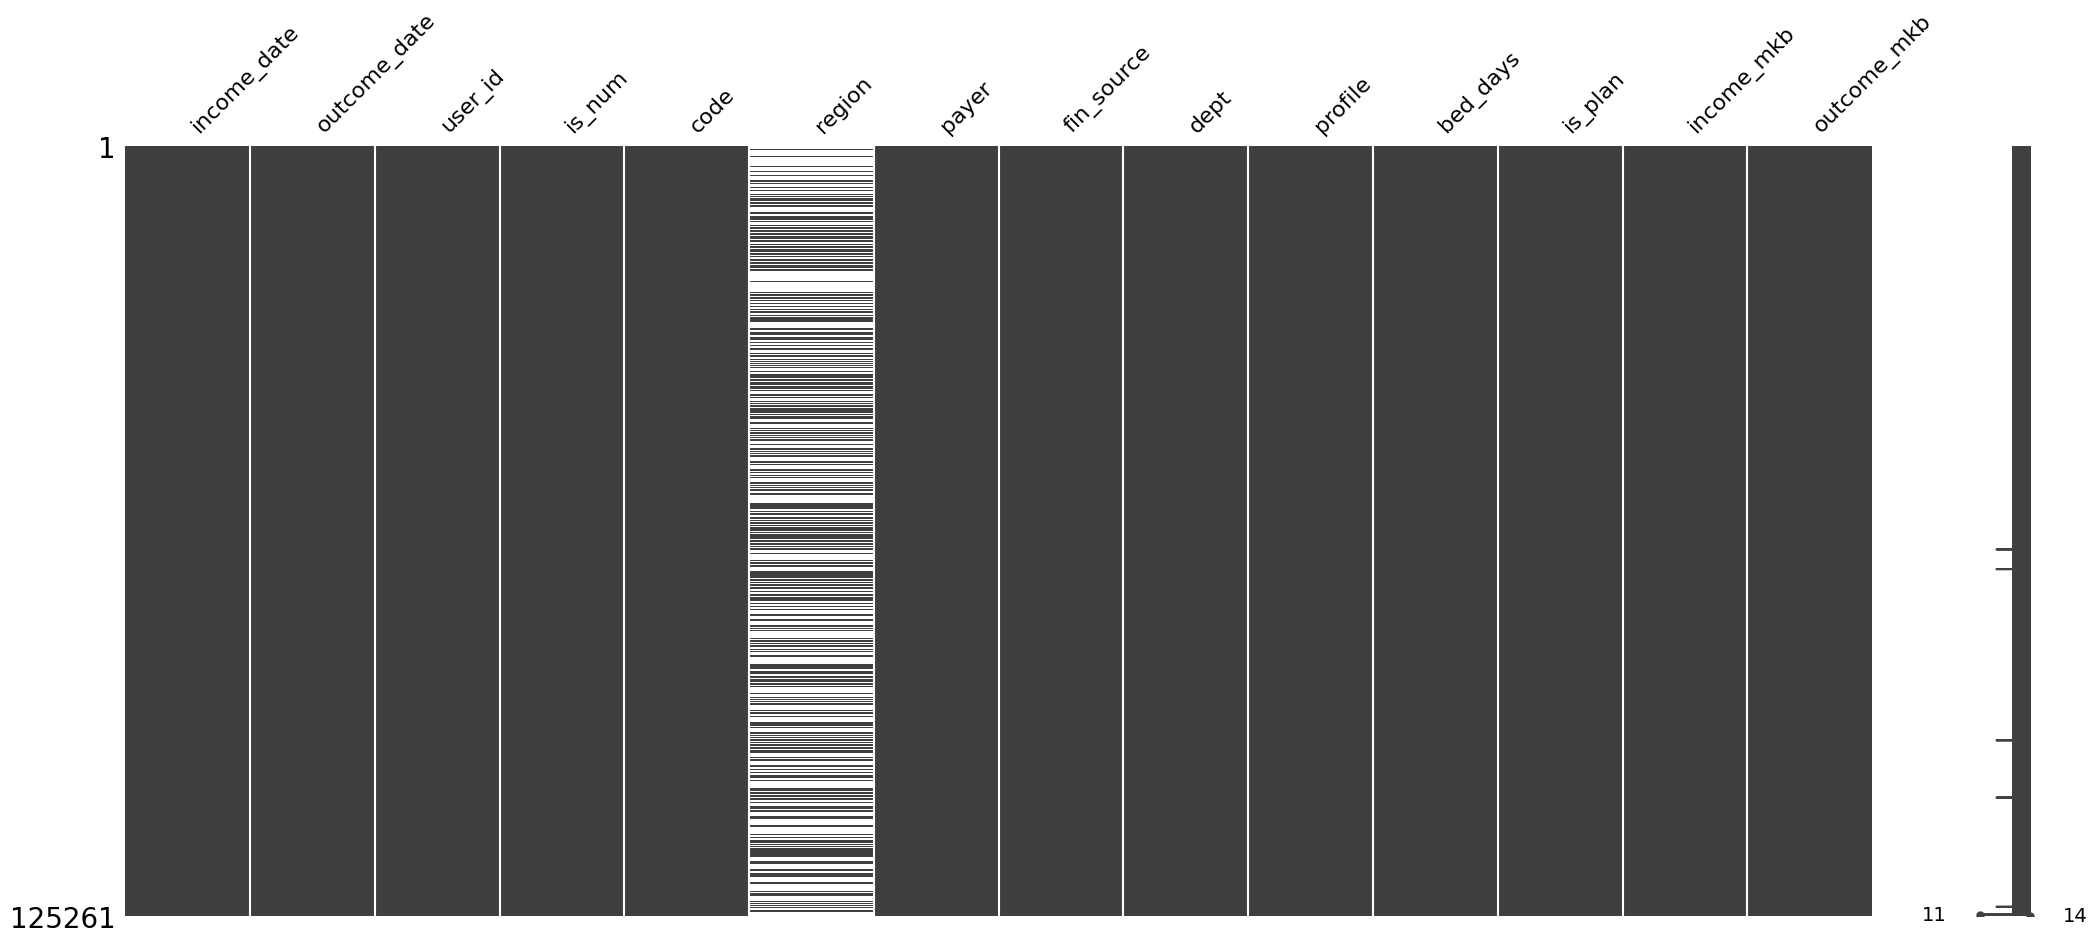

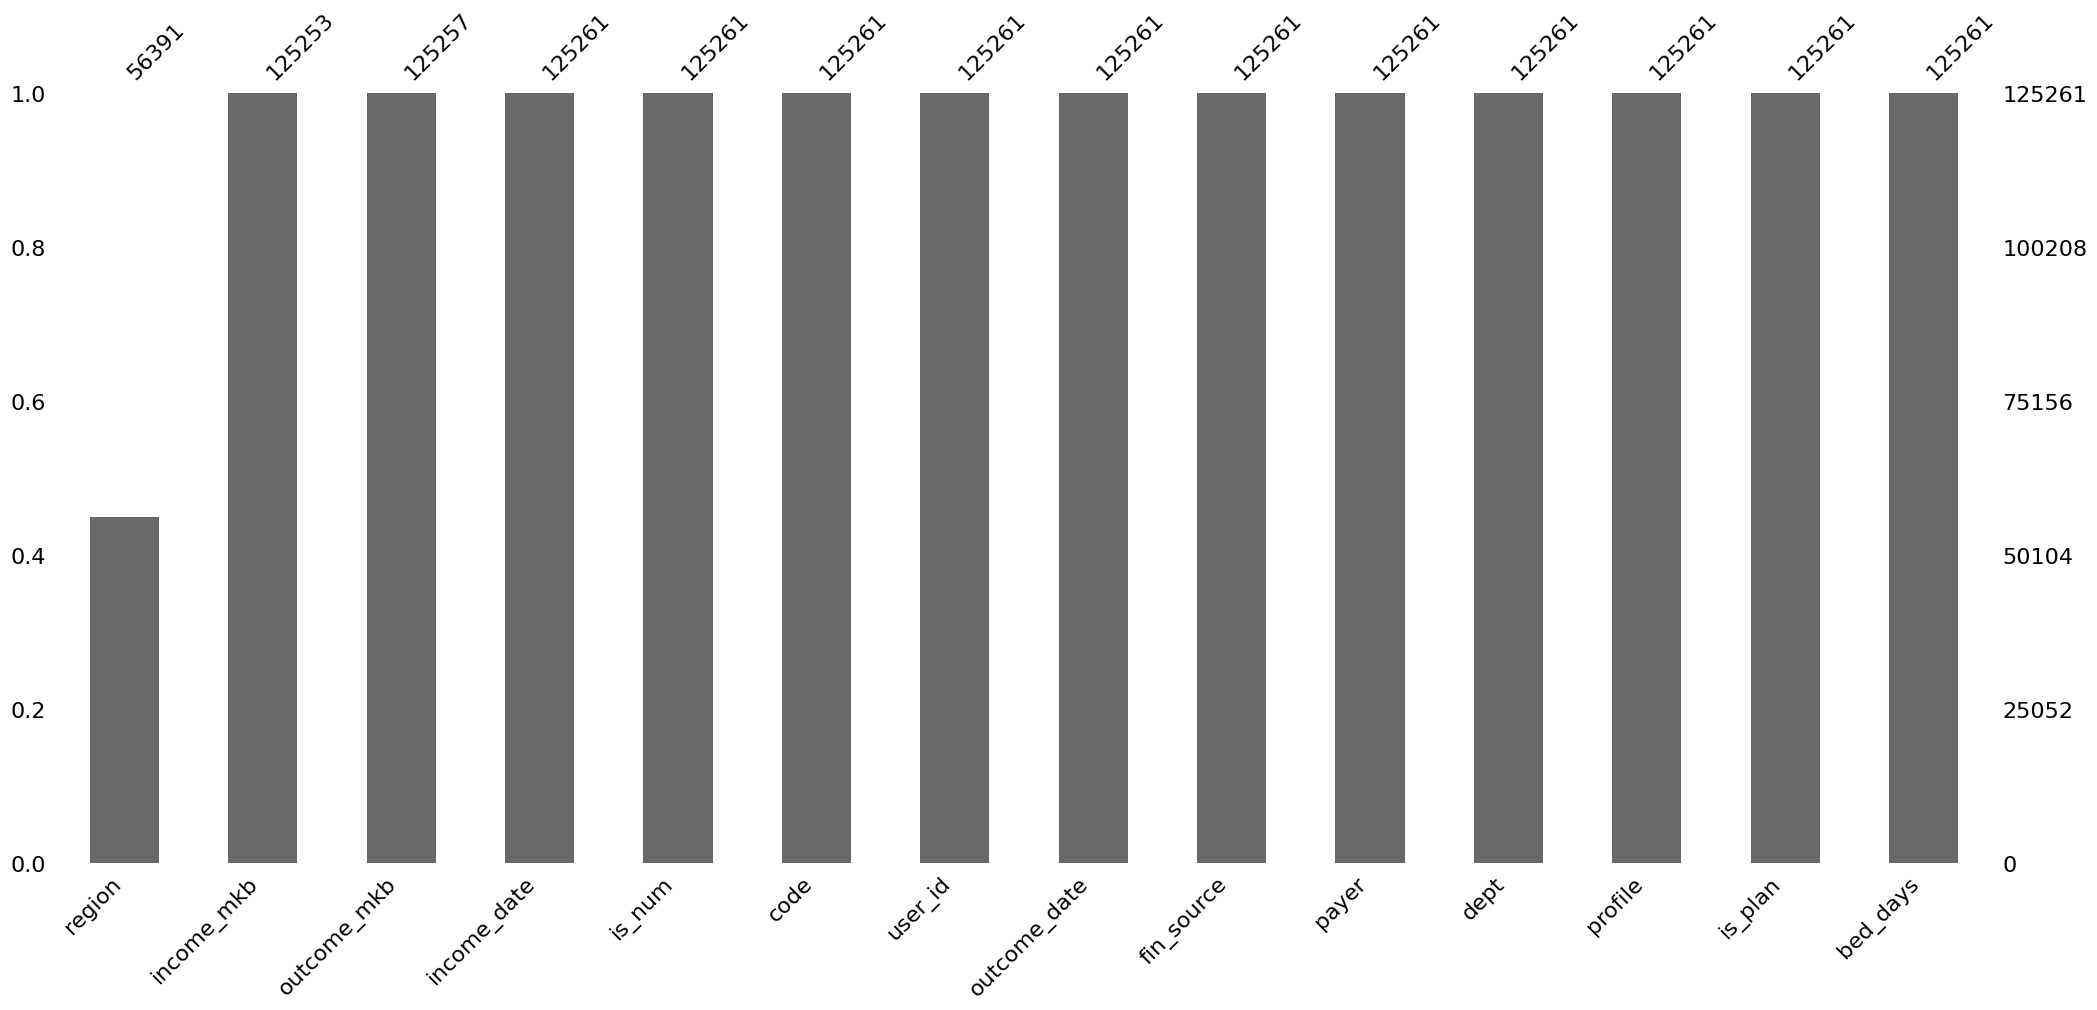

In [7]:
plt.figure(figsize=(10, 4))
msno.matrix(hospital)
plt.show()

plt.figure(figsize=(10, 4))
msno.bar(hospital, sort='ascending')
plt.show()


In [8]:
# Удаляем строки с пропусками в кодах МКБ (их доля мала)
hospital = hospital.dropna(subset=['income_mkb', 'outcome_mkb'])

# Удаляем столбец region: восстановить значения невозможно,
# а пропусков слишком много
hospital = hospital.drop(columns=['region'])

# Проверяем, что пропусков больше нет
hospital.isnull().sum().sort_values(ascending=False)


,0
income_date,0
outcome_date,0
user_id,0
is_num,0
code,0
payer,0
fin_source,0
dept,0
profile,0
bed_days,0


- Основной объём пропусков приходился на столбец `region`, а также на поля `income_mkb` и `outcome_mkb`, однако доля пропусков в кодах МКБ была незначительной.
- Для дальнейшего анализа строки с отсутствующими кодами диагнозов были удалены, а столбец `region` исключён из датафрейма из‑за большого числа пропусков и отсутствия возможности корректного восстановления значений. После обработки в данных не осталось пропусков.

###2.4. Приведение типов данных  

In [9]:
# Посмотрим, сколько памяти занимает датафрейм до оптимизации
mem_before = hospital.memory_usage(deep=True).sum() / 1024**2  # в МБ
print(f'Память до приведения типов: {mem_before:.2f} MB')

Память до приведения типов: 115.53 MB


In [10]:
hospital['income_date'] = pd.to_datetime(
    hospital['income_date'],
    format='%d.%m.%Y'
)
hospital['outcome_date'] = pd.to_datetime(
    hospital['outcome_date'],
    format='%d.%m.%Y'
)

In [11]:
hospital['bed_days'] = hospital['bed_days'].astype('int64')

hospital['user_id'] = hospital['user_id'].astype('int64')
hospital['is_num'] = hospital['is_num'].astype('int64')


In [12]:
cat_cols = [
    'fin_source',
    'dept',
    'profile',
    'is_plan',
    'payer',
    'region'
]

for col in cat_cols:
    if col in hospital.columns:
        hospital[col] = hospital[col].astype('category')


In [13]:
hospital.dtypes


,0
income_date,datetime64[ns]
outcome_date,datetime64[ns]
user_id,int64
is_num,int64
code,object
payer,category
fin_source,category
dept,category
profile,category
bed_days,int64


In [14]:
mem_after = hospital.memory_usage(deep=True).sum() / 1024**2  # в МБ

abs_save = mem_before - mem_after
rel_save = abs_save / mem_before * 100

print(f'Память до приведения типов: {mem_before:.2f} MB')
print(f'Память после приведения типов: {mem_after:.2f} MB')
print(f'Абсолютная экономия памяти: {abs_save:.2f} MB')
print(f'Относительная экономия памяти: {rel_save:.2f}%')


Память до приведения типов: 115.53 MB
Память после приведения типов: 25.84 MB
Абсолютная экономия памяти: 89.70 MB
Относительная экономия памяти: 77.64%


- После приведения типов данных датафрейм **hospital** стал заметно компактнее по использованию памяти. Объём памяти снизился с 115.53 MB до 25.84 MB, то есть на 89.70 MB, что составляет 77.64% от исходного объёма.
- Это произошло за счёт преобразования текстовых дат в тип `datetime`, числовых признаков в целочисленный формат `int64`, а категориальных признаков — в тип `category`, что сделало данные более эффективными по памяти и удобными для последующего анализа.

###2.5. Анализ и обработка дубликатов

In [15]:
# Выделим все полные дубликаты (по всем столбцам)
hospital_full_duplicates = hospital[hospital.duplicated(keep=False)]

# Посмотрим, сколько полных дубликатов есть в датасете
hospital_full_duplicates.shape

(8820, 13)

In [16]:
hospital_full_duplicates.head()

,income_date,outcome_date,user_id,is_num,code,payer,fin_source,dept,profile,bed_days,is_plan,income_mkb,outcome_mkb
550,2019-01-14,2019-01-31,994080000,732,5.99.0,Фонд-Иногородние,ОМС,Кожно-венерологическое отделение,Дерматологические,18,Плановая,L20.8,L20.8
551,2019-01-14,2019-01-31,994080000,732,5.99.0,Фонд-Иногородние,ОМС,Кожно-венерологическое отделение,Дерматологические,18,Плановая,L20.8,L20.8
578,2019-01-14,2019-01-29,268622000,780,5.5.1,"Филиал ОАО ""СОГАЗ"" в Санкт-Петербурге",ОМС,Кожно-венерологическое отделение,Дерматологические,16,Плановая,L94.0,L94.0
579,2019-01-14,2019-01-29,268622000,780,5.5.1,"Филиал ОАО ""СОГАЗ"" в Санкт-Петербурге",ОМС,Кожно-венерологическое отделение,Дерматологические,16,Плановая,L94.0,L94.0
622,2019-01-15,2019-01-25,762227000,844,5.4.1,"ОАО ""ГСМК"" СПб",ОМС,Кожно-венерологическое отделение,Дерматологические,11,Плановая,L20.9,L20.8


In [17]:
# Удалим полные дубликаты, оставив первую встреченную строку
hospital = hospital.drop_duplicates(keep='first')

hospital.shape

(120836, 13)

- Мы загрузили датасет `hospital`, переименовали столбцы в удобный латинский формат и проанализировали пропуски.
- Строки с отсутствующими кодами диагнозов были удалены, столбец `region` исключён из‑за большого числа пропусков и невозможности корректно восстановить значения.
- Далее мы привели типы данных: даты перевели в `datetime`, числовые признаки — в `int64`, категориальные поля — в `category`, что сократило объём памяти с 115.53 MB до 25.84 MB (экономия 77.64%).
- В завершение удалили полные дубликаты строк, после чего в датафрейме осталось 120 836 записей и 13 столбцов.


## 3. Исследовательский анализ данных
---

###3.1. Распределение длительности госпитализации

In [18]:
# Минимум и максимум длительности госпитализации
hospital['bed_days'].min(), hospital['bed_days'].max()

(1, 266)

In [26]:
# Интерактивная гистограмма длительности госпитализации
fig_hist = px.histogram(
    hospital,
    x='bed_days',
    nbins=30,
    title='Распределение длительности госпитализации (койко-дни)',
    labels={'bed_days': 'Количество дней лечения в стационаре'},
)
fig_hist.update_traces(marker_line_color='black', marker_line_width=1)
fig_hist.update_layout(
    bargap=0.05,
    plot_bgcolor='white',
    paper_bgcolor='white',
    xaxis_showgrid=False,
    yaxis_showgrid=False
)
fig_hist.show()

In [25]:
fig_box = px.box(
    hospital,
    x='bed_days',
    title='Boxplot длительности госпитализации',
    labels={'bed_days': 'Количество дней лечения в стационаре'},
)
fig_box.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    xaxis_showgrid=False,
    yaxis_showgrid=False
)
fig_box.show()

In [21]:
# Описательные статистики длительности госпитализации
bed_stats = hospital['bed_days'].describe()
iqr = bed_stats['75%'] - bed_stats['25%']
bed_stats, iqr

(count    120836.000000
 mean          8.728508
 std           8.765610
 min           1.000000
 25%           3.000000
 50%           7.000000
 75%          12.000000
 max         266.000000
 Name: bed_days, dtype: float64,
 np.float64(9.0))

###3.2. Средняя длительность по отделениям (топ‑10)  

###3.3. Динамика количества поступлений по месяцам и годам

## 4. Проверка статистических гипотез
---

###4.1. Проверка отклонения от стандартного срока 7 дней  

###4.2. Проверка гипотезы «средняя длительность > 10 дней»  

###4.3. Сравнение длительности лечения у плановых и экстренных пациентов

## 5. Выводы
---

###5.1. Обзор проделанной работы

###5.2. Ключевые выводы

###5.3. Рекомендации для заказчика